<a href="https://colab.research.google.com/github/rmarharyta/machinelearning/blob/main/%D0%9B%D0%A04_%D0%A0%D1%83%D0%B1%D0%BB%D0%B5%D0%BD%D0%BA%D0%BE_4_10_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №4. Регресійні моделі: глибоке дослідження

**Датасет:** Car Price Prediction Multiple Linear Regression  
https://www.kaggle.com/datasets/hellbuoy/car-price-prediction?select=CarPrice_Assignment.csv

**Мета роботи:** виконати підготовку даних, побудувати та порівняти регресійні моделі для прогнозування ціни автомобіля, оцінити їх якість і проаналізувати отримані результати.

> У шаблоні наведено лише умови завдань. Реалізацію необхідно виконати самостійно у порожніх комірках.


**Автор роботи: Рубленко Маргарита Віталіївна ФІТ 4-10**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Завантаження та первинний аналіз даних

Завантажити датасет та виконати його первинний огляд:
- визначити кількість об'єктів і ознак;
- переглянути назви стовпців;
- визначити типи даних;
- визначити цільову змінну;
- вивести основні статистичні характеристики даних.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-price-prediction' dataset.
Path to dataset files: /kaggle/input/car-price-prediction


In [ ]:
df = pd.read_csv(path + "/CarPrice_Assignment.csv")
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [ ]:
print("Кількість об'єктів:", df.shape[0])
print("Кількість ознак:", df.shape[1])

print("\nНазви стовпців:")
print(df.columns.tolist())

print("\nТипи даних:")
print(df.dtypes)

print("\nЦільова змінна: price")

print("\nОсновні статистичні характеристики:")
display(df.describe())

Кількість об'єктів: 205
Кількість ознак: 26

Назви стовпців:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']

Типи даних:
car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    f

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## 2. Перевірка якості даних

Перевірити:
- наявність пропущених значень;
- наявність повних дублікатів;
- кількість унікальних значень в ознаках.

Під час аналізу врахувати, що `car_ID` є унікальним ідентифікатором автомобіля і сам по собі не повинен використовуватися для визначення дублікатів за змістовими характеристиками.


In [ ]:
print("Пропущені значення:")
print(df.isnull().sum())

Пропущені значення:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


In [ ]:
print("\nПовні дублікати:")
print(df.duplicated().sum())


Повні дублікати:
0


In [ ]:
print("\nДублікати за змістовими характеристиками без car_ID:")
print(df.drop(columns=['car_ID']).duplicated().sum())


Дублікати за змістовими характеристиками без car_ID:
0


In [ ]:
print("\nКількість унікальних значень:")
print(df.nunique())


Кількість унікальних значень:
car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
price               189
dtype: int64


## 3. Робота з car_ID

Зберегти `car_ID` окремо для подальшої ідентифікації автомобілів у результатах прогнозування.  
Не використовувати `car_ID` як ознаку під час навчання моделей.


In [ ]:
car_ids = df['car_ID'].copy()

df_model = df.drop(columns=['car_ID'])

print("car_ID збережено окремо.")
print("Кількість ID:", len(car_ids))

print("\nПерші 10 car_ID:")
print(car_ids.head(10).to_list())

car_ID збережено окремо.
Кількість ID: 205

Перші 10 car_ID:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## 4. Дослідження розподілів числових ознак

Дослідити розподіли числових ознак:
- побудувати відповідні графіки;
- обчислити коефіцієнти асиметрії;
- визначити ознаки з найбільш вираженою асиметрією;
- коротко прокоментувати отримані результати.


Числові ознаки:
['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']

Коефіцієнти асиметрії:


,Skewness
compressionratio,2.610862
enginesize,1.947655
price,1.777678
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997
symboling,0.211072


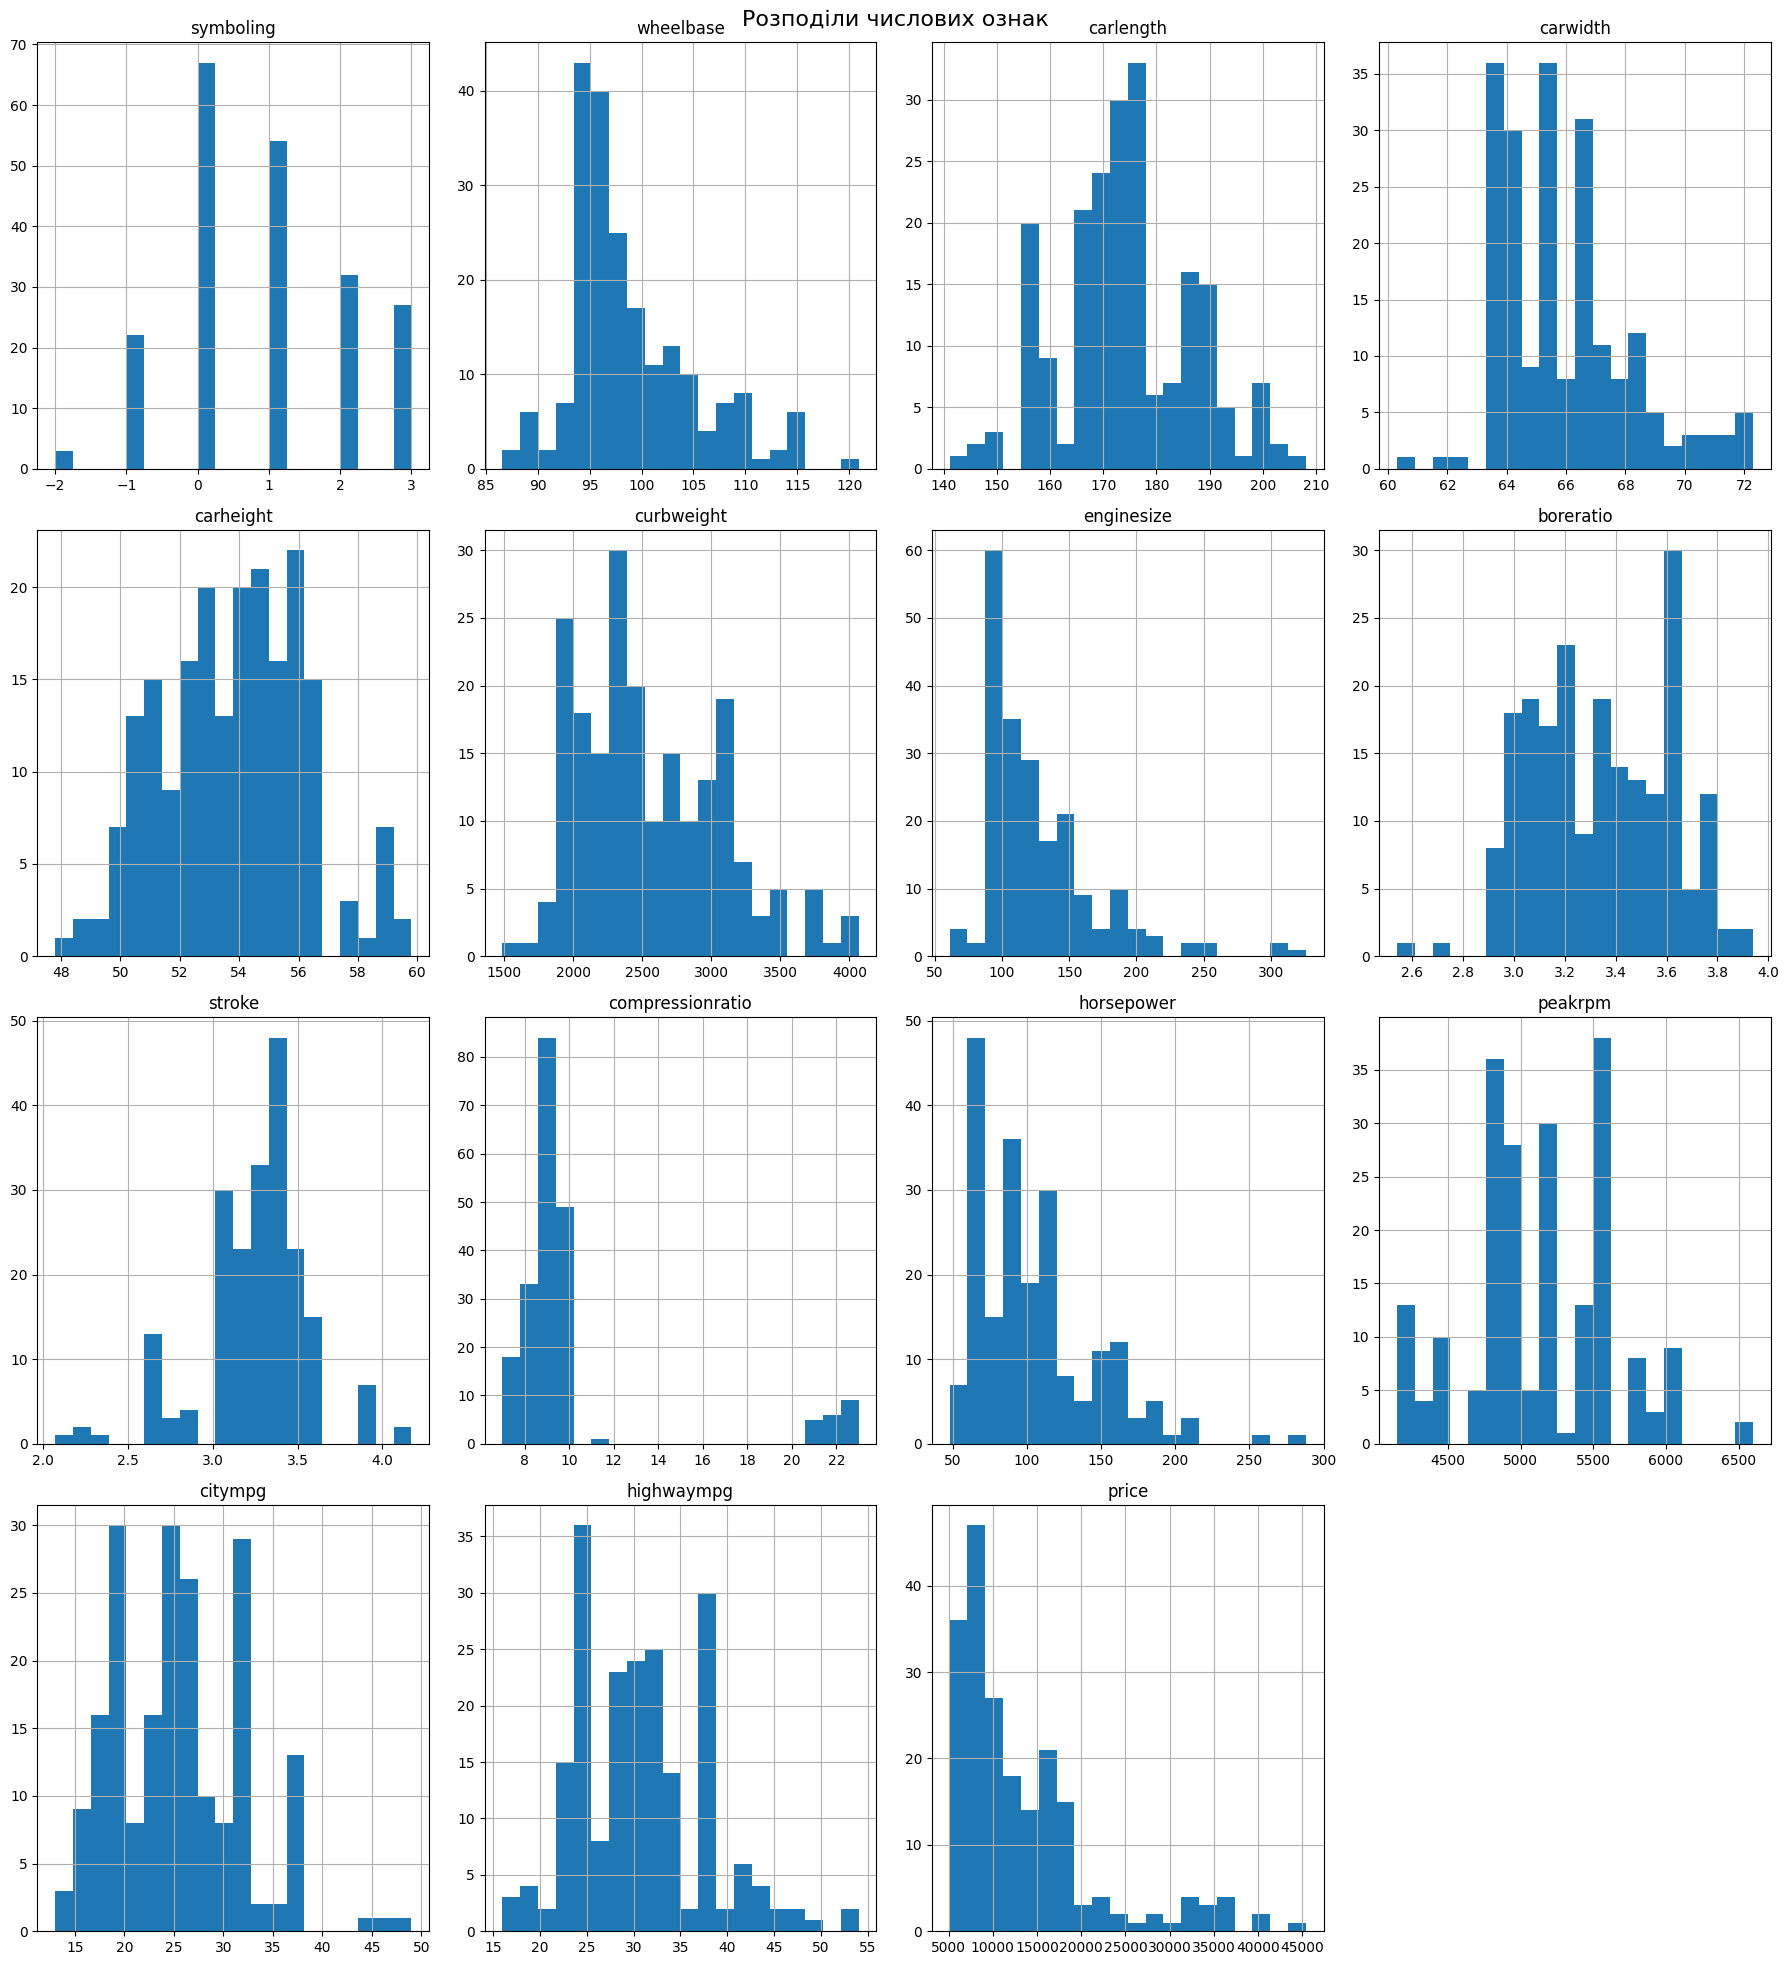

In [ ]:
numeric_columns = df_model.select_dtypes(include=np.number).columns.tolist()

print("Числові ознаки:")
print(numeric_columns)

skewness = df_model[numeric_columns].skew().sort_values(ascending=False)

print("\nКоефіцієнти асиметрії:")
display(skewness.to_frame(name='Skewness'))

df_model[numeric_columns].hist(
    figsize=(18, 20),
    bins=20
)

plt.suptitle("Розподіли числових ознак", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
print("Найбільш асиметричні ознаки:")

most_skewed = skewness.abs().sort_values(ascending=False).head(10)

display(most_skewed.to_frame(name='Absolute Skewness'))

Найбільш асиметричні ознаки:


,Absolute Skewness
compressionratio,2.610862
enginesize,1.947655
price,1.777678
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
stroke,0.689705
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997


## 5. Формування train/test вибірок

Відокремити цільову змінну `price` від ознак та розділити дані на:
- навчальну вибірку — 80%;
- тестову вибірку — 20%.

Забезпечити відтворюваність поділу.  
Окремо зберегти `car_ID` для об'єктів, які потрапили до train і test.

**Важливо:** усі подальші параметри передобробки даних визначати тільки за навчальною вибіркою.


In [ ]:
from sklearn.model_selection import train_test_split

y = df['price']

X = df.drop(columns=['car_ID', 'price'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

car_id_train = df.loc[X_train.index, 'car_ID']
car_id_test = df.loc[X_test.index, 'car_ID']

print("Розмір X_train:", X_train.shape)
print("Розмір X_test:", X_test.shape)

print("\nРозмір y_train:", y_train.shape)
print("Розмір y_test:", y_test.shape)

print("\nКількість car_ID у train:", len(car_id_train))
print("Кількість car_ID у test:", len(car_id_test))

Розмір X_train: (164, 24)
Розмір X_test: (41, 24)

Розмір y_train: (164,)
Розмір y_test: (41,)

Кількість car_ID у train: 164
Кількість car_ID у test: 41


In [ ]:
print("Частка train:", len(X_train) / len(df))
print("Частка test:", len(X_test) / len(df))

Частка train: 0.8
Частка test: 0.2


## 6. Аналіз та обробка викидів

Для неперервних числових ознак навчальної вибірки:
- визначити потенційні викиди методом IQR;
- вивести кількість потенційних викидів для кожної ознаки;
- обґрунтувати спосіб їх обробки.

Для невеликого набору даних не видаляти автоматично всі рядки з викидами. Використати обмеження крайніх значень межами, визначеними за навчальною вибіркою.

Цільову змінну `price` не використовувати для визначення меж викидів.  
До тестової вибірки застосувати ті самі межі, які були отримані за train.


In [ ]:
continuous_features = [
    col for col in X_train.select_dtypes(include=np.number).columns
    if col != 'symboling']

print("Неперервні числові ознаки:")
print(continuous_features)

Неперервні числові ознаки:
['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']


In [ ]:
outlier_bounds = {}

outlier_counts = {}

for col in continuous_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_bounds[col] = (lower_bound, upper_bound)

    count = ((X_train[col] < lower_bound) |
             (X_train[col] > upper_bound)).sum()

    outlier_counts[col] = count

outlier_table = pd.DataFrame({
    'Ознака': list(outlier_counts.keys()),
    'Кількість викидів': list(outlier_counts.values())})

display(outlier_table)

,Ознака,Кількість викидів
0,wheelbase,6
1,carlength,0
2,carwidth,10
3,carheight,0
4,curbweight,0
5,enginesize,7
6,boreratio,1
7,stroke,16
8,compressionratio,20
9,horsepower,7


In [ ]:
X_train_clipped = X_train.copy()
X_test_clipped = X_test.copy()

for col, (lower, upper) in outlier_bounds.items():
    X_train_clipped[col] = X_train_clipped[col].clip(
        lower=lower,
        upper=upper)

    X_test_clipped[col] = X_test_clipped[col].clip(
        lower=lower,
        upper=upper)

print("Обробку викидів завершено.")

Обробку викидів завершено.


## 7. Аналіз кореляцій та відбір ознак

За навчальною вибіркою:
- побудувати матрицю кореляцій числових ознак;
- знайти пари ознак із сильною кореляцією, для яких `|r| > 0.85`;
- для кожної такої пари залишити одну ознаку;
- під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною `price`;
- вивести список сильно корельованих пар та перелік ознак, які видаляються.

Із тестової вибірки видалити ті самі ознаки.  
Не використовувати тестову вибірку для прийняття рішення про відбір ознак.


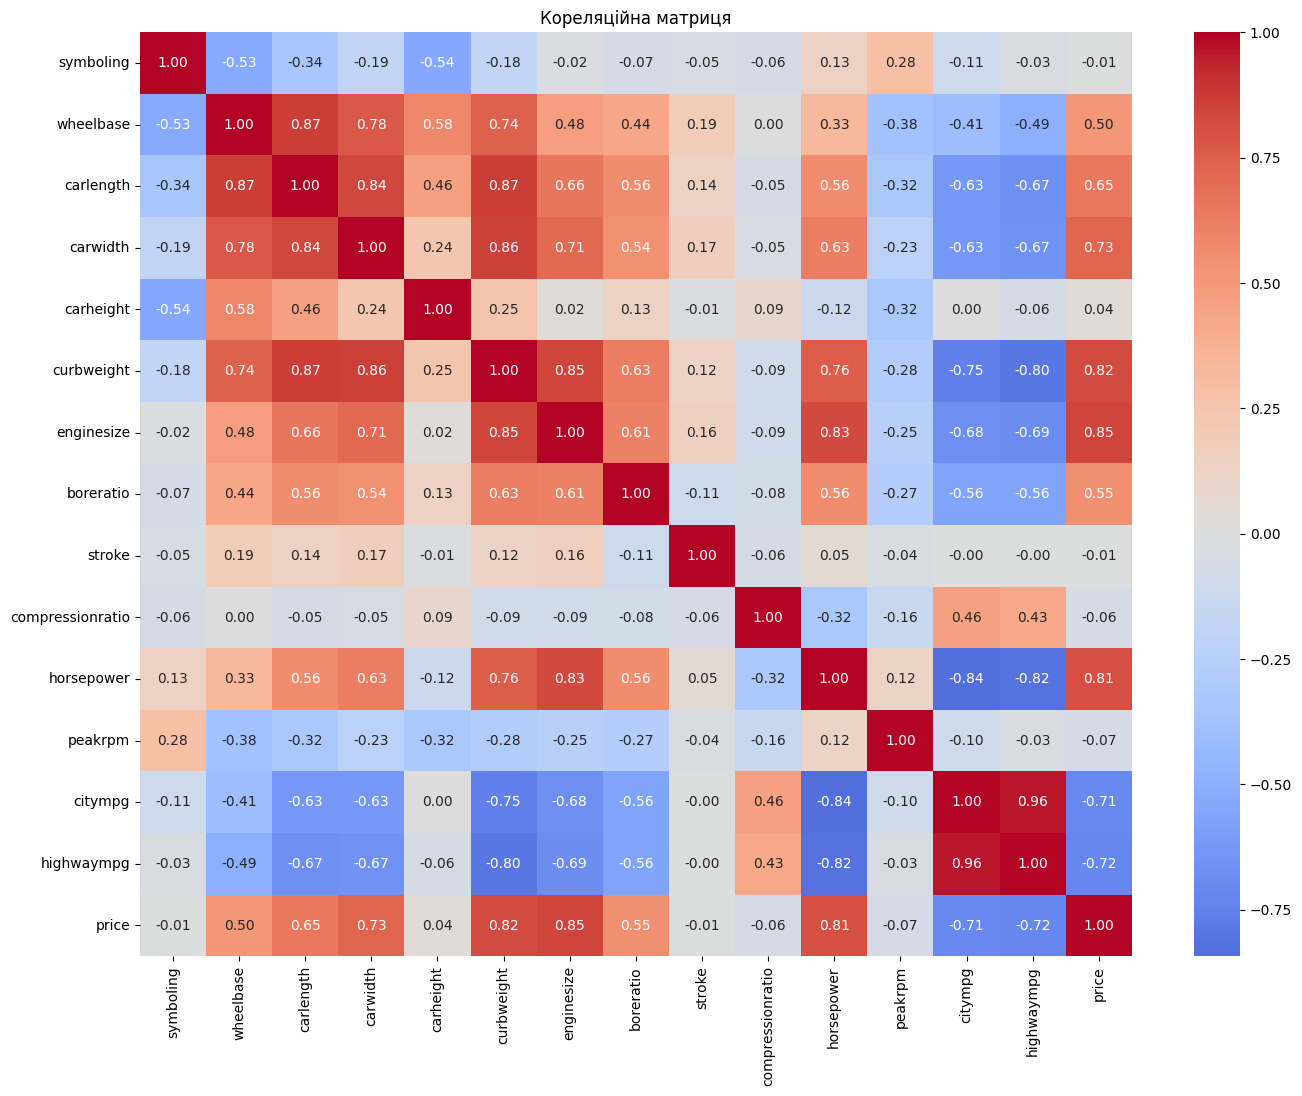

In [ ]:
corr_matrix = X_train_clipped.select_dtypes(include=np.number).copy()

corr_with_price = corr_matrix.copy()
corr_with_price['price'] = y_train

correlation_matrix = corr_with_price.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0)

plt.title("Кореляційна матриця")
plt.show()

In [ ]:
numeric_for_corr = X_train_clipped.select_dtypes(include=np.number)

strong_pairs = []

columns = numeric_for_corr.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        corr_value = numeric_for_corr[columns[i]].corr(
            numeric_for_corr[columns[j]])

        if abs(corr_value) > 0.85:
            strong_pairs.append({
                'Ознака 1': columns[i],
                'Ознака 2': columns[j],
                'Кореляція': corr_value})

strong_pairs_df = pd.DataFrame(strong_pairs)

print("Сильно корельовані пари:")
display(strong_pairs_df)

Сильно корельовані пари:


,Ознака 1,Ознака 2,Кореляція
0,wheelbase,carlength,0.867043
1,carlength,curbweight,0.865988
2,carwidth,curbweight,0.858047
3,citympg,highwaympg,0.963620


In [ ]:
price_correlations = X_train_clipped.select_dtypes(include=np.number).corrwith(y_train).abs()

features_to_drop = set()

for _, row in strong_pairs_df.iterrows():
    feature1 = row['Ознака 1']
    feature2 = row['Ознака 2']

    corr1 = price_correlations[feature1]
    corr2 = price_correlations[feature2]

    if corr1 >= corr2:
        features_to_drop.add(feature2)
    else:
        features_to_drop.add(feature1)

print("Ознаки, які будуть видалені:")
print(sorted(features_to_drop))

Ознаки, які будуть видалені:
['carlength', 'carwidth', 'citympg', 'wheelbase']


In [ ]:
X_train_selected = X_train_clipped.drop(
    columns=list(features_to_drop))

X_test_selected = X_test_clipped.drop(
    columns=list(features_to_drop))

print("Розмір X_train після відбору:", X_train_selected.shape)
print("Розмір X_test після відбору:", X_test_selected.shape)

Розмір X_train після відбору: (164, 20)
Розмір X_test після відбору: (41, 20)


## 8. Підготовка числових і категоріальних ознак

Розділити ознаки на:
- неперервні числові;
- дискретну числову ознаку `symboling`;
- категоріальні.

Для неперервних числових ознак виконати послідовно:
1. перетворення Yeo–Johnson для зменшення асиметрії;
2. масштабування за допомогою StandardScaler.

Для `symboling` виконати масштабування без Yeo–Johnson.

Категоріальні ознаки закодувати методом One-Hot Encoding. Передбачити коректну обробку категорій у test, яких не було у train.

Усі перетворення об'єднати в єдиний механізм передобробки даних, який навчається тільки на `X_train`.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    PowerTransformer,
    StandardScaler,
    OneHotEncoder)

continuous_features = [
    col for col in X_train_selected.select_dtypes(include=np.number).columns
    if col != 'symboling']

symboling_features = ['symboling'] if 'symboling' in X_train_selected.columns else []

categorical_features = X_train_selected.select_dtypes(
    include=['object']).columns.tolist()

print("Неперервні числові:")
print(continuous_features)

print("\nДискретна числова:")
print(symboling_features)

print("\nКатегоріальні:")
print(categorical_features)

Неперервні числові:
['carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'highwaympg']

Дискретна числова:
['symboling']

Категоріальні:
['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


In [ ]:
continuous_pipeline = Pipeline([
    ('yeo_johnson', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())])

symboling_pipeline = Pipeline([
    ('scaler', StandardScaler())])

categorical_pipeline = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False)

preprocessor = ColumnTransformer([
    ('continuous', continuous_pipeline, continuous_features),
    ('symboling', symboling_pipeline, symboling_features),
    ('categorical', categorical_pipeline, categorical_features)])

print("Передобробку даних створено.")

Передобробку даних створено.


## 9. Перевірка трансформації числових ознак

Перевірити результат трансформації неперервних числових ознак:
- застосувати до train ту саму послідовність перетворень, яка буде використана в моделях;
- повторно обчислити коефіцієнти асиметрії;
- порівняти їх із початковими значеннями;
- зробити короткий висновок щодо ефективності трансформації.


In [ ]:
skew_before = X_train_selected[continuous_features].skew()

print("Асиметрія ДО Yeo-Johnson:")
display(skew_before.to_frame(name='Skewness before'))

Асиметрія ДО Yeo-Johnson:


,Skewness before
carheight,0.028154
curbweight,0.712433
enginesize,0.962394
boreratio,0.062963
stroke,-0.397600
compressionratio,0.055710
horsepower,0.850735
peakrpm,0.039773
highwaympg,0.243761


In [ ]:
preprocessor.fit(X_train_selected)

X_train_transformed = preprocessor.transform(X_train_selected)

print("Розмір трансформованих даних:", X_train_transformed.shape)

Розмір трансформованих даних: (164, 171)


In [ ]:
yeo_transformer = preprocessor.named_transformers_['continuous'].named_steps['yeo_johnson']

X_continuous_yeo = yeo_transformer.transform(
    X_train_selected[continuous_features])

X_continuous_yeo_df = pd.DataFrame(
    X_continuous_yeo,
    columns=continuous_features,
    index=X_train_selected.index)

skew_after = X_continuous_yeo_df.skew()

comparison = pd.DataFrame({
    'До Yeo-Johnson': skew_before,
    'Після Yeo-Johnson': skew_after,
    'Абсолютна асиметрія до': skew_before.abs(),
    'Абсолютна асиметрія після': skew_after.abs()})

display(comparison)

,До Yeo-Johnson,Після Yeo-Johnson,Абсолютна асиметрія до,Абсолютна асиметрія після
carheight,0.028154,-0.005170,0.028154,0.005170
curbweight,0.712433,0.049894,0.712433,0.049894
enginesize,0.962394,0.044834,0.962394,0.044834
boreratio,0.062963,-0.005941,0.062963,0.005941
stroke,-0.397600,0.015846,0.397600,0.015846
compressionratio,0.055710,0.004872,0.055710,0.004872
horsepower,0.850735,0.066280,0.850735,0.066280
peakrpm,0.039773,-0.003589,0.039773,0.003589
highwaympg,0.243761,-0.012188,0.243761,0.012188


## 10. Побудова регресійних моделей

Побудувати та навчити такі моделі:
- Linear Regression;
- Ridge Regression;
- Lasso Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- Support Vector Regressor (SVR).

Для кожної моделі створити єдиний Pipeline, який містить:
1. попередню обробку ознак;
2. відповідну регресійну модель.

Використати однакову схему підготовки даних для коректного порівняння моделей.


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

models = {
    'Linear Regression': LinearRegression(),

    'Ridge Regression': Ridge(alpha=1.0),

    'Lasso Regression': Lasso(
        alpha=0.001,
        max_iter=10000),

    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        random_state=42),

    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42),

    'SVR': SVR(
        kernel='rbf',
        C=100,
        epsilon=0.1)
    }

print("Completed")

Completed


In [ ]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

print("Створено Pipeline для:")
for name in pipelines:
    print("-", name)

Створено Pipeline для:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest
- Gradient Boosting
- SVR


In [ ]:
for name, pipeline in pipelines.items():
    pipeline.fit(X_train_selected, y_train)
    print(f"{name}: навчено")

Linear Regression: навчено
Ridge Regression: навчено


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.941e+07, tolerance: 9.781e+05
  model = cd_fast.enet_coordinate_descent(


Lasso Regression: навчено
Random Forest: навчено
Gradient Boosting: навчено
SVR: навчено


## 11. Оцінювання якості моделей

Для кожної моделі:
- виконати навчання на тренувальній вибірці;
- отримати прогноз для тестової вибірки;
- обчислити метрики **R², MAE, MSE та MAPE**.

`MAPE` подати у відсотках.

Результати всіх моделей об'єднати в одну порівняльну таблицю та впорядкувати за значенням R² від найбільшого до найменшого.

Під час інтерпретації врахувати:
- R² — чим більше, тим краще;
- MAE, MSE, MAPE — чим менше, тим краще.


In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error)

results = []

predictions = {}

for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test_selected)

    predictions[name] = y_pred

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results.append({
        'Model': name,
        'R²': r2,
        'MAE': mae,
        'MSE': mse,
        'MAPE (%)': mape})

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='R²',
    ascending=False).reset_index(drop=True)

display(results_df)

,Model,R²,MAE,MSE,MAPE (%)
0,Random Forest,0.950934,1424.397593,3.873485e+06,10.344366
1,Gradient Boosting,0.927281,1720.463991,5.740708e+06,12.992404
2,Ridge Regression,0.795685,2712.767719,1.612942e+07,23.065284
3,Linear Regression,0.548073,4078.229150,3.567691e+07,29.972020
4,Lasso Regression,0.374544,4421.735492,4.937601e+07,30.178598
5,SVR,0.107508,4578.154212,7.045688e+07,25.859541


In [ ]:
best_model_name = results_df.iloc[0]['Model']
print(f"{best_model_name}")

Random Forest


## 12. Пояснення вибору типу моделі

Пояснити, чому класифікаційна модель, наприклад Logistic Regression, не підходить для безпосереднього прогнозування неперервної ціни автомобіля.

Зазначити, до якого типу задачі належить прогнозування `price` та чому моделі, використані в роботі, відповідають цій задачі.


Прогнозування ціни авто — це задача регресії, бо ціна є конкретним числом, тоді як логістична регресія не підходить, оскільки створена для класифікації, поділу на категорії на кшталт «дорого/дешево», а не для пошуку точної суми. Тому замість неї для отримання числових прогнозів використовують інші регресійні моделі: лінійні алгоритми (Linear Regression, Ridge, Lasso), дерева рішень (Random Forest, Gradient Boosting) та метод опорних векторів (SVR).

## 13. Візуальне порівняння прогнозів

Для кожної побудованої моделі зобразити співвідношення:
- фактичних значень `price`;
- прогнозованих значень `price`.

Додати лінію ідеального прогнозу та проаналізувати, наскільки близько до неї розташовані прогнозовані значення. Звернути увагу на великі відхилення.


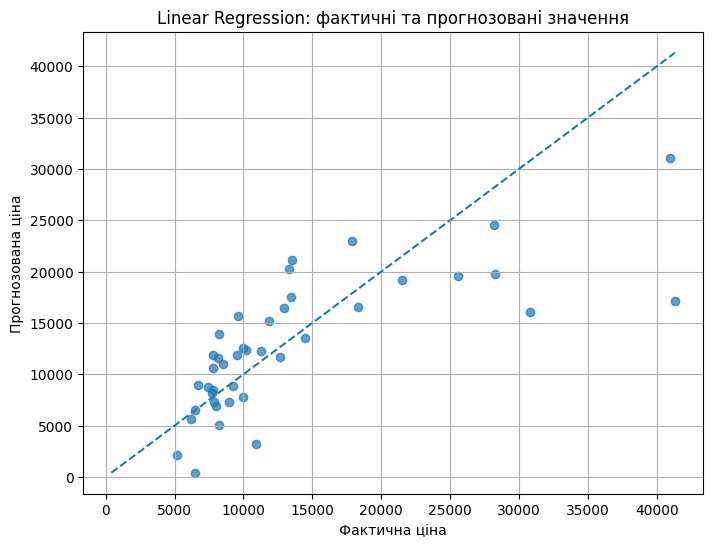

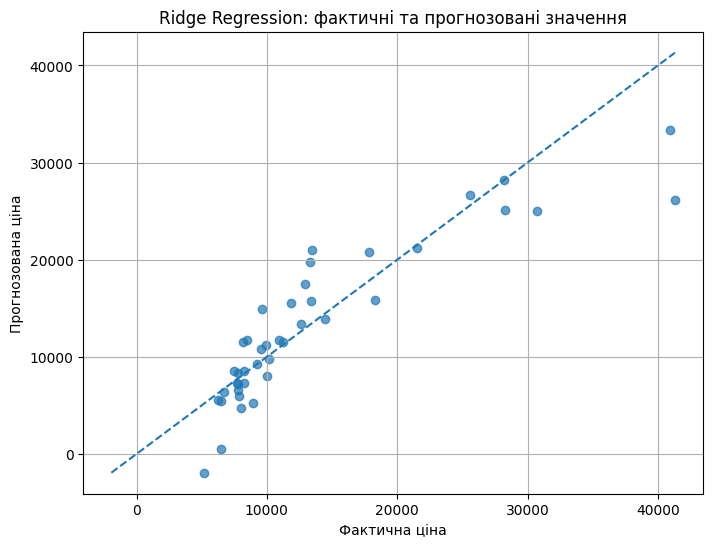

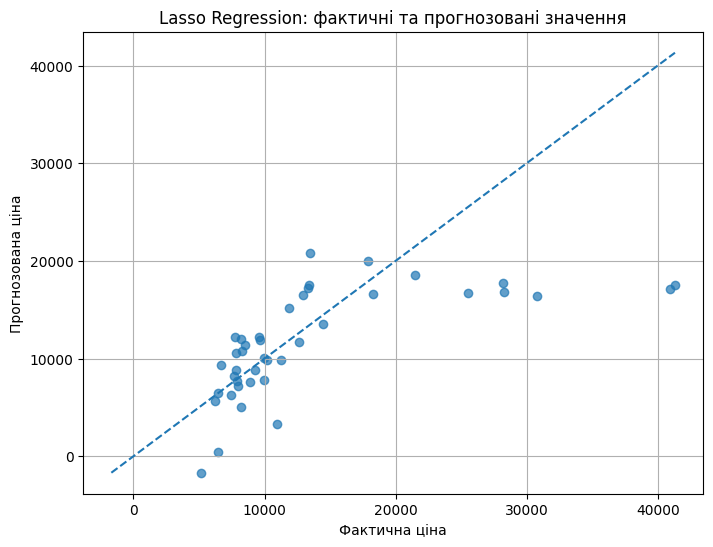

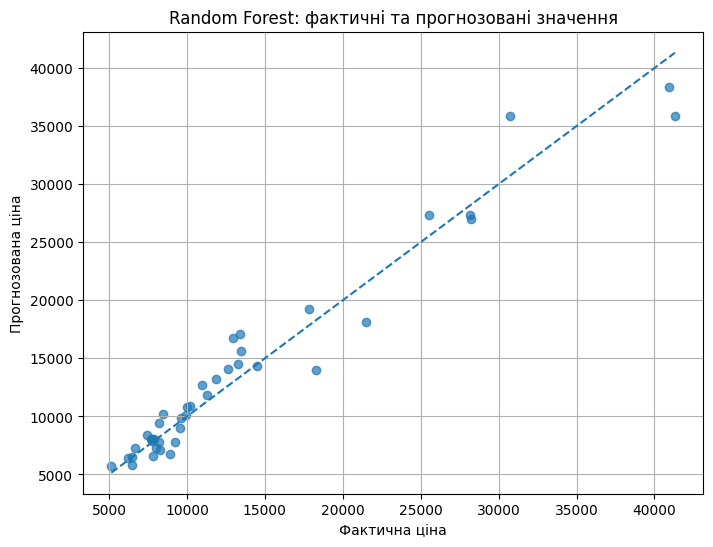

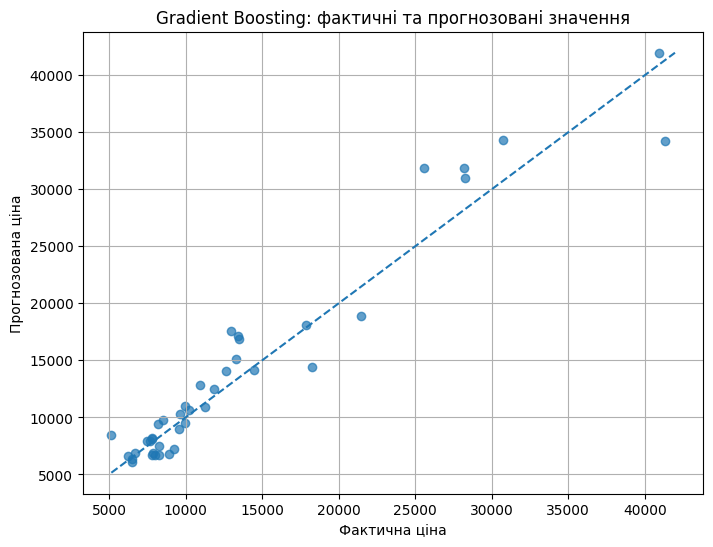

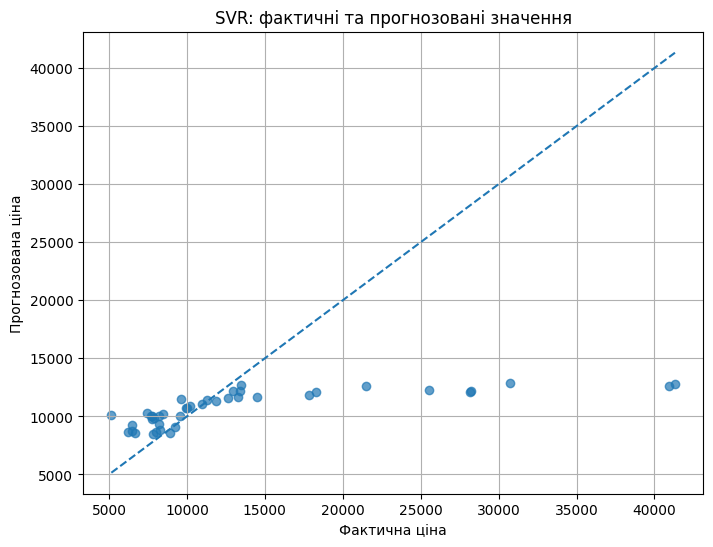

In [ ]:
for name, y_pred in predictions.items():

    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.7)

    min_value = min(y_test.min(), y_pred.min())
    max_value = max(y_test.max(), y_pred.max())

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle='--')

    plt.xlabel("Фактична ціна")
    plt.ylabel("Прогнозована ціна")
    plt.title(f"{name}: фактичні та прогнозовані значення")

    plt.grid(True)
    plt.show()

## 14. Прогноз для 10 автомобілів

Випадково вибрати 10 автомобілів із тестової вибірки.

За допомогою моделі Random Forest отримати для них прогноз ціни та сформувати таблицю з такими даними:
- `car_ID`;
- фактична ціна;
- прогнозована ціна;
- абсолютна помилка;
- абсолютна відсоткова помилка.

Прокоментувати отримані результати.


In [ ]:
sample_indices = X_test_selected.sample(
    n=10,
    random_state=42).index

X_sample = X_test_selected.loc[sample_indices]
y_sample = y_test.loc[sample_indices]
id_sample = car_id_test.loc[sample_indices]

rf_predictions = pipelines['Random Forest'].predict(X_sample)

absolute_error = abs(y_sample.values - rf_predictions)

absolute_percentage_error = (
    absolute_error / y_sample.values) * 100

prediction_table = pd.DataFrame({
    'car_ID': id_sample.values,
    'Фактична ціна': y_sample.values,
    'Прогнозована ціна': rf_predictions,
    'Абсолютна помилка': absolute_error,
    'Абсолютна відсоткова помилка (%)': absolute_percentage_error})

display(prediction_table.round(2))

,car_ID,Фактична ціна,Прогнозована ціна,Абсолютна помилка,Абсолютна відсоткова помилка (%)
0,26,6692.0,7256.92,564.92,8.44
1,176,9988.0,10805.55,817.55,8.19
2,148,10198.0,10871.77,673.77,6.61
3,17,41315.0,35845.66,5469.34,13.24
4,69,28248.0,26983.71,1264.29,4.48
5,147,7463.0,8422.47,959.47,12.86
6,144,9960.0,10085.13,125.13,1.26
7,85,14489.0,14357.93,131.07,0.90
8,195,12940.0,16727.40,3787.40,29.27
9,160,7788.0,7867.79,79.79,1.02


In [ ]:
print("Середня абсолютна помилка:")
print(round(prediction_table['Абсолютна помилка'].mean(), 2))

print("\nСередня абсолютна відсоткова помилка:")
print(round(prediction_table['Абсолютна відсоткова помилка (%)'].mean(), 2), "%")

Середня абсолютна помилка:
1387.27

Середня абсолютна відсоткова помилка:
8.63 %


## 15. Висновки

Сформулювати підсумкові висновки за результатами роботи.

У висновках:
- порівняти якість усіх моделей;
- проаналізувати R², MAE, MSE і MAPE;
- зазначити, яка модель показала найкращі результати за отриманими метриками;
- прокоментувати величину похибок;
- звернути увагу на можливі ознаки перенавчання;
- коротко оцінити вплив попередньої обробки даних на результати моделювання.


In [ ]:
# Найкраща модель за R^2
best_r2_model = results_df.loc[
    results_df['R²'].idxmax(),
    'Model'
]

# Найменша MAE
best_mae_model = results_df.loc[
    results_df['MAE'].idxmin(),
    'Model'
]

# Найменша MSE
best_mse_model = results_df.loc[
    results_df['MSE'].idxmin(),
    'Model'
]

# Найменша MAPE
best_mape_model = results_df.loc[
    results_df['MAPE (%)'].idxmin(),
    'Model'
]

print("Найкраща модель за R²:", best_r2_model)
print("Найкраща модель за MAE:", best_mae_model)
print("Найкраща модель за MSE:", best_mse_model)
print("Найкраща модель за MAPE:", best_mape_model)

Найкраща модель за R²: Random Forest
Найкраща модель за MAE: Random Forest
Найкраща модель за MSE: Random Forest
Найкраща модель за MAPE: Random Forest


У лабораторній роботі було виконано підготовку даних та побудовано шість регресійних моделей для прогнозування ціни автомобілів. Дані розділено на навчальну та тестову вибірки у співвідношенні 80/20. Проведено обробку викидів методом IQR, перетворення Yeo-Johnson, масштабування та кодування категоріальних ознак.

Якість моделей оцінено за метриками R², MAE, MSE та MAPE. Найкращу модель визначено за отриманими результатами. Попередня обробка даних допомогла підготувати ознаки для моделювання. Можливе перенавчання оцінюється шляхом порівняння результатів на train і test.


## Загальні вимоги до виконання

- Не використовувати тестову вибірку для визначення меж викидів, кореляційного відбору ознак, навчання трансформерів, масштабування або кодування категорій.
- Усі параметри передобробки мають визначатися тільки за навчальною вибіркою.
- Фінальні метрики моделей обчислювати на тестовій вибірці.
- Не використовувати `car_ID` як предиктор.
- Не видаляти спостереження або ознаки без пояснення причини.
- До кожного основного етапу додати короткий змістовний висновок.
- У підсумкових висновках спиратися на отримані метрики та графіки.
